# Reasoning as an observed behavior: agreement vs. realized reasoning length


Run from the repository root or from `notebooks/`. The values are computed from the aggregated
results in `results/*-aggregated-0-bullet-is.csv` and the per-run predictions under
`$REASONANCE_RESULTS_ROOT`, and cached in `results/pair-values/` (`refresh=True` recomputes).
Figures are only shown here (`save=False`); pass `save=True` to write them to
`results/figures/paper/`.

Paper figures in this notebook:

- main text: `fig:agree-length`, `fig:length-recourse`
- appendix: `fig:appendix-length-agree-by-dev-details`, `fig:appendix-length-agree-by-dev-x-axis`,
  `fig:appendix-length-agree-observed`, `fig:appendix-length-vote-excess-joint`,
  `fig:appendix-length-recourse-by-label`

**How to read this notebook.** The x axis sorts INDIVIDUALS by the length they drew; no model's
budget is raised anywhere. A falling curve says *the people the models think about longest are the
people they split on*, not *thinking longer makes models disagree*. The manipulated version of the
question -- same person, bigger budget -- is the effort comparison in `2-reasoning-effort.ipynb`.

In [ ]:
import os
from pathlib import Path

# every path in `reasonance` is relative to the repository root
if Path.cwd().name == "notebooks":
    os.chdir(Path.cwd().parent)

import matplotlib.pyplot as plt
from reasonance.analysis import (
    length_curves_for_tasks,
    pair_length_curves_for_tasks,
)
from reasonance.paper_figures import (
    length_main,
    length_pairs,
    length_vote_distribution,
    length_vote_excess,
    task_ylims,
)
from reasonance.plotting import set_figure_prefix, set_plot_style

QA_MODE = "numeric"
set_plot_style()
set_figure_prefix(QA_MODE)  # the tasks are panels, so only the QA mode is in the file name

('numeric',)

## Agreement vs. how long the models actually thought

Paper: `fig:agree-length`.

One panel per task, the matched reasoning runs pooled over developers, with the OpenAI effort
levels beside them in shades of the same blue (pooled darkest, then high, medium, low). Individuals
are binned by their reasoning length (percentile rank within a run: the only definition comparable
across models with different token scales and immune to the output cap); the level curves use the
SAME bins, so a vertical slice compares the same individuals. Thin lines are seed draws -- draw r
takes every model's r-th seed, so they are disjoint replicates of the whole curve.

Reasoning runs only: the non-reasoning runs have no length of their own.

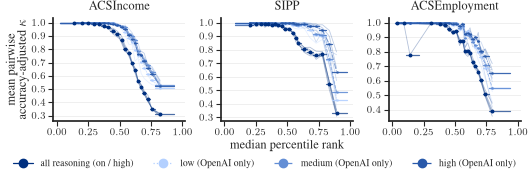

In [2]:
# the matched reasoning runs pooled over developers, one panel per task;
# the split by developer, with the OpenAI effort levels, follows below
length_curves = length_curves_for_tasks(variant="rank", refresh=True)
length_main(data=length_curves, families=("All",), save=False)  # levels default to low/medium/high
plt.show()

## Split by developer, and on the other two length axes

Paper: `fig:appendix-length-agree-by-dev-details`, `fig:appendix-length-agree-by-dev-x-axis`.

Columns are tasks, rows are developer groups, so the three groups of one task are read down a
column on a shared y. y is shared per COLUMN only: the tasks sit at different levels and forcing
one scale across all nine panels would flatten the curves. The OpenAI models are the only ones with
effort levels, which is what the `(OpenAI only)` labels say. `raw` keeps token units but is not
comparable across models (Alibaba writes thousands of tokens, the GPTs hundreds); `zscore` removes
each run's scale but divides by its own spread, so a run that writes the same amount for everyone
has its noise stretched over the axis.

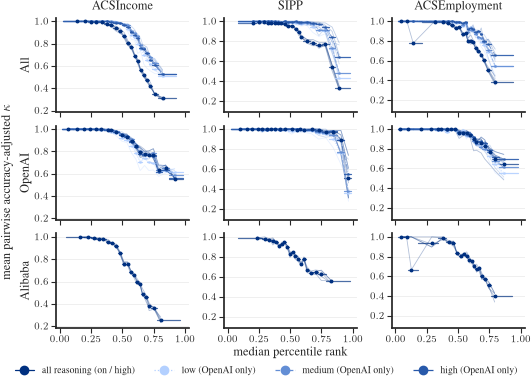

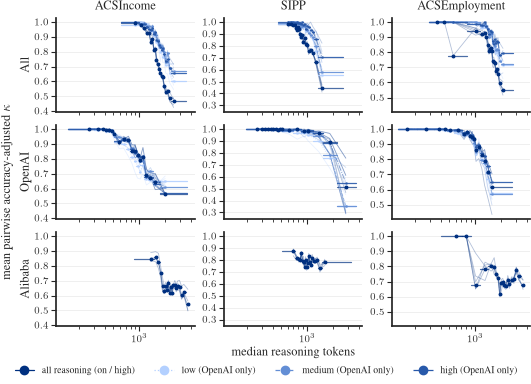

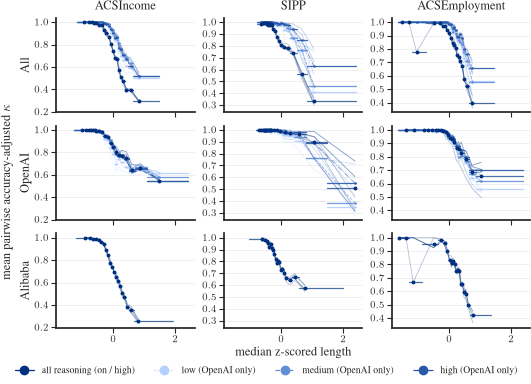

In [3]:
# every task x developer, with the OpenAI effort levels.
# ylim is shared with the per-pair figure below so the two can be stacked as subfigures.
length_ylims = task_ylims(length_curves)
length_main(data=length_curves, ylim=length_ylims, save=False)
plt.show()

for _variant in ("raw", "zscore"):
    length_main(variant=_variant, refresh=True, save=False)
    plt.show()

### Per model pair, each on its own length

Paper: `fig:appendix-length-agree-by-dev-details` (right panel).

One thin line per model pair, binned by the length THAT pair produced, so nothing is borrowed from
models outside the pair. Reasoning only, colored by developer, with the OpenAI effort levels added.
Seeds: the two models of a pair are balanced to the same number of seeds, the pair's components are
averaged over its cross-seed run pairs, and its length is the mean over those same runs. Across
lines the bins are not the same individuals -- read the shapes and the within-line gaps, not a
vertical slice. Drawn on the ylim of the developer figure above, to stack as subfigures.

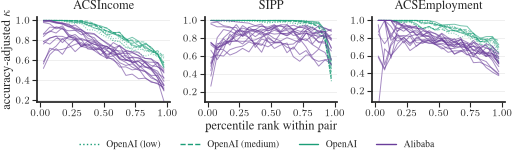

In [4]:
pair_curves = pair_length_curves_for_tasks(variant="rank", levels=("low", "medium"), refresh=True)
length_pairs(data=pair_curves, ylim=length_ylims, save=False)
plt.show()

## Raw observed agreement, with the accuracy of the same runs

Paper: `fig:appendix-length-agree-observed`.

The paper metric divides out each pair's accuracy baseline. This is the undivided version: how
often two runs say the same thing, without asking whether accuracy alone explains it. The green
right-hand axis carries the mean accuracy of the same runs on the same bins -- the obvious objection
to the falling curve is that the models are simply wrong about the long individuals. Accuracy does
fall with length, but far less steeply than agreement does.

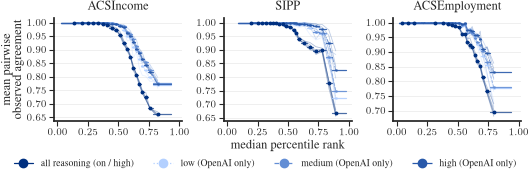

In [5]:
# recomputed with the observed metric: the curves above hold the paper metric
length_main(metric="observed", families=("All",), refresh=True, save=False)
plt.show()

## Vote distributions along the length axis

The vote distributions of the effort notebook, cut by realized reasoning length: the bins,
individuals and seed draws of `fig:agree-length`, and the number of correct predictions among the
nine matched models. Reasoning runs only.

- **excess** -- do the models agree more than their accuracy explains? Observed share minus
  independent models with the bin's own accuracies. It separates agreement from accuracy but hides
  the absolute level.
- **observed distribution** -- how many individuals get nine correct answers and how many are
  contested. It shows the absolute level but cannot separate agreement from accuracy.

### Where the agreement beyond accuracy sits

Paper: `fig:length-recourse`.

One column per task. Top: the excess over independent errors (share of a bin's individuals at a
vote count, minus what nine independent models with that bin's own accuracies would give) for three
levels -- all nine wrong, all nine correct, and a split vote (4 or 5 of 9 correct) -- as stairs, one
value per bin. Bottom: the observed vote distribution those lines come from.

Votes are averaged over seed draws (one seed per model per draw). The flat zero at the short end of
ACSEmployment is not missing data: there every run is right about everyone, so independent models
would be unanimous too and there is nothing in excess.

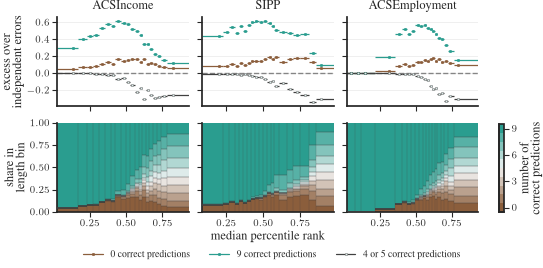

In [6]:
length_vote_excess(refresh=True, save=False)
plt.show()

### The excess at every vote count

Paper: `fig:appendix-length-vote-excess-joint`.

The main-text figure with a heatmap on top: the excess at every vote count (red: more individuals
than independence predicts, blue: fewer). Within a bin the excess sums to zero over the vote counts,
so the heatmap shows where the mass at the unanimous ends comes from.

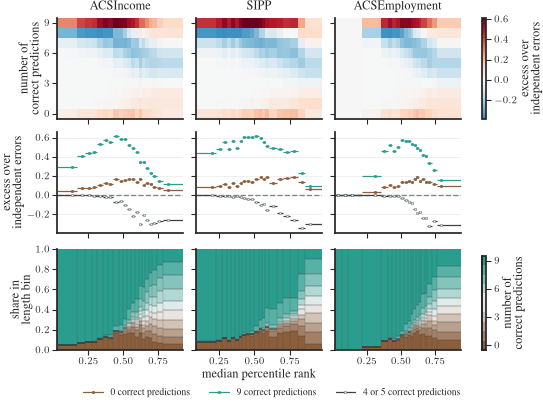

In [7]:
length_vote_excess(joint=True, save=False)
plt.show()

### The vote distribution, conditioned on the true label

Paper: `fig:appendix-length-recourse-by-label`.

One row per true label. Each column is one length bin of `fig:agree-length`, split by label: a
column normalizes within its row (the share among that bin's individuals of that label), so the two
halves of a bin can be very different in size. A bin holding fewer than 30 individuals of a label is
left empty rather than drawn from a handful of people.

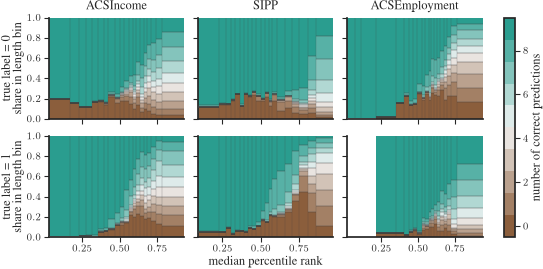

In [8]:
length_vote_distribution(mode="correct", variant="rank", by_label=True, refresh=True, save=False)
plt.show()